## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters

In [2]:
start = np.array([0, 0])
end = np.array([100, 100])
num_waypoints = 6
num_food = 10
num_hazards = 10
num_particles = 30
num_iterations = 100

## PSO parameters

In [3]:
w = 0.5       # inertia
c1 = 1.5      # cognitive coefficient
c2 = 1.5      # social coefficient

## Randomly generate food and hazards

In [4]:
food_sources = np.random.uniform(0, 100, (num_food, 2))
hazards = np.random.uniform(0, 100, (num_hazards, 2))

## Define utility functions

In [5]:
def distance(p1, p2):
    return np.linalg.norm(p1 - p2)

def energy_cost(path):
    """
    Calculates total energy based on:
    - distance between consecutive points
    - wind effect (favor wind in x+y direction)
    - altitude effect (higher altitude costs more)
    - proximity to food (reduce energy)
    - proximity to hazards (increase energy)
    """
    total_energy = 0
    full_path = np.vstack([start, path, end])
    
    for i in range(len(full_path)-1):
        segment = full_path[i+1] - full_path[i]
        dist = np.linalg.norm(segment)
        
        # Wind effect: if flying along vector (1,1) reduces energy
        wind = np.dot(segment, np.array([1,1])) / (np.linalg.norm(segment) + 1e-6)
        wind_effect = -0.1 * wind  # negative means helps reduce energy
        
        # Altitude effect: simple model, y-coordinate as altitude
        altitude_effect = 0.01 * full_path[i+1][1]
        
        # Food effect: closer to food reduces energy
        food_dist = np.min(np.linalg.norm(food_sources - full_path[i+1], axis=1))
        food_effect = -0.05 / (food_dist + 1e-6)
        
        # Hazard effect: closer to hazard increases energy
        hazard_dist = np.min(np.linalg.norm(hazards - full_path[i+1], axis=1))
        hazard_effect = 0.2 / (hazard_dist + 1e-6)
        
        total_energy += dist + wind_effect + altitude_effect + food_effect + hazard_effect
        
    return total_energy

## Initialize PSO particles

In [6]:
particles = np.random.uniform(0, 100, (num_particles, num_waypoints, 2))
velocities = np.random.uniform(-5, 5, (num_particles, num_waypoints, 2))

# Personal best
pBest = particles.copy()
pBest_scores = np.array([energy_cost(p) for p in particles])

# Global best
gBest_idx = np.argmin(pBest_scores)
gBest = pBest[gBest_idx].copy()
gBest_score = pBest_scores[gBest_idx]


## PSO main loop

In [7]:
for iter in range(num_iterations):
    for i in range(num_particles):
        r1, r2 = np.random.rand(), np.random.rand()
        velocities[i] = (w * velocities[i] 
                         + c1 * r1 * (pBest[i] - particles[i]) 
                         + c2 * r2 * (gBest - particles[i]))
        particles[i] += velocities[i]
        
        # Keep particles within bounds
        particles[i] = np.clip(particles[i], 0, 100)
        
        # Evaluate
        score = energy_cost(particles[i])
        if score < pBest_scores[i]:
            pBest[i] = particles[i].copy()
            pBest_scores[i] = score
    
    # Update global best
    gBest_idx = np.argmin(pBest_scores)
    gBest = pBest[gBest_idx].copy()
    gBest_score = pBest_scores[gBest_idx]
    
    if iter % 10 == 0:
        print(f"Iteration {iter}, Best Energy: {gBest_score:.4f}")


Iteration 0, Best Energy: 234.1773
Iteration 10, Best Energy: 157.6651
Iteration 20, Best Energy: 153.6838
Iteration 30, Best Energy: 146.0201
Iteration 40, Best Energy: 145.9122
Iteration 50, Best Energy: 145.8941
Iteration 60, Best Energy: 145.8933
Iteration 70, Best Energy: 145.8933
Iteration 80, Best Energy: 145.8932
Iteration 90, Best Energy: 145.8930


## Output optimal path

In [ ]:
optimal_path = np.vstack([start, gBest, end])
print("Optimal Waypoints:")
print(optimal_path)

## Visualization

Iteration 0, Best Energy: 230.4470
Iteration 10, Best Energy: 148.8323
Iteration 20, Best Energy: 146.2543
Iteration 30, Best Energy: 145.3964
Iteration 40, Best Energy: 145.3586
Iteration 50, Best Energy: 145.3538
Iteration 60, Best Energy: 145.3472
Iteration 70, Best Energy: 145.3395
Iteration 80, Best Energy: 145.3227
Iteration 90, Best Energy: 145.2944
Optimal Waypoints:
[[  0.           0.        ]
 [ 43.21056206  44.83283424]
 [ 54.02957719  56.05859213]
 [ 54.03077824  56.05930366]
 [ 54.49797271  56.43877316]
 [ 65.79362347  67.34789796]
 [ 83.51038941  85.35054173]
 [100.         100.        ]]


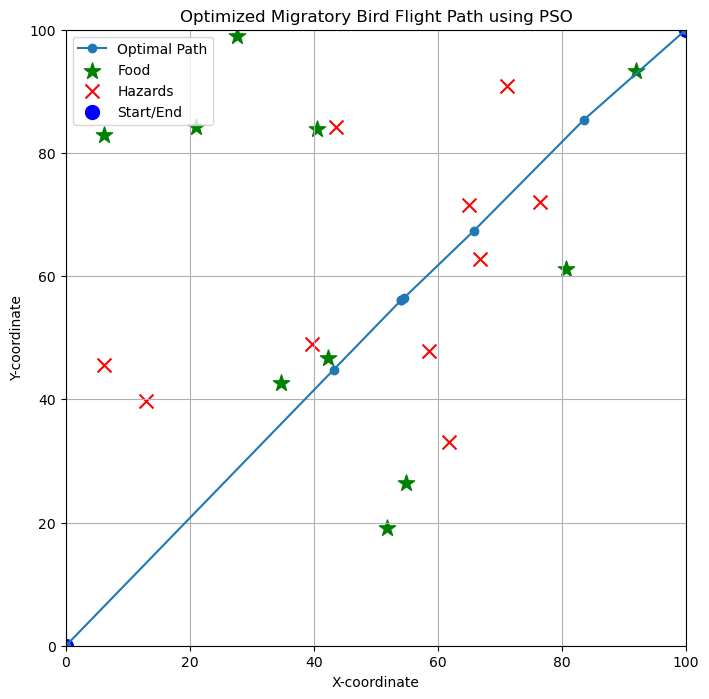

In [1]:
plt.figure(figsize=(8,8))
plt.plot(optimal_path[:,0], optimal_path[:,1], '-o', label='Optimal Path')
plt.scatter(food_sources[:,0], food_sources[:,1], c='green', marker='*', s=150, label='Food')
plt.scatter(hazards[:,0], hazards[:,1], c='red', marker='x', s=100, label='Hazards')
plt.scatter([0,100],[0,100], c='blue', s=100, label='Start/End')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()
plt.title("Optimized Migratory Bird Flight Path using PSO")
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.grid(True)
plt.show()
